# Manifold learning (_Swiss Roll_)

In [1]:
from experiments.utils.constants import RANDOM_SEED

VERBOSE = True
MANIFOLD_NAME = "Swiss Roll"

from experiments.utils.data_manifold import generate_swiss_roll
MANIFOLD_GENERATOR = generate_swiss_roll

## Dataset

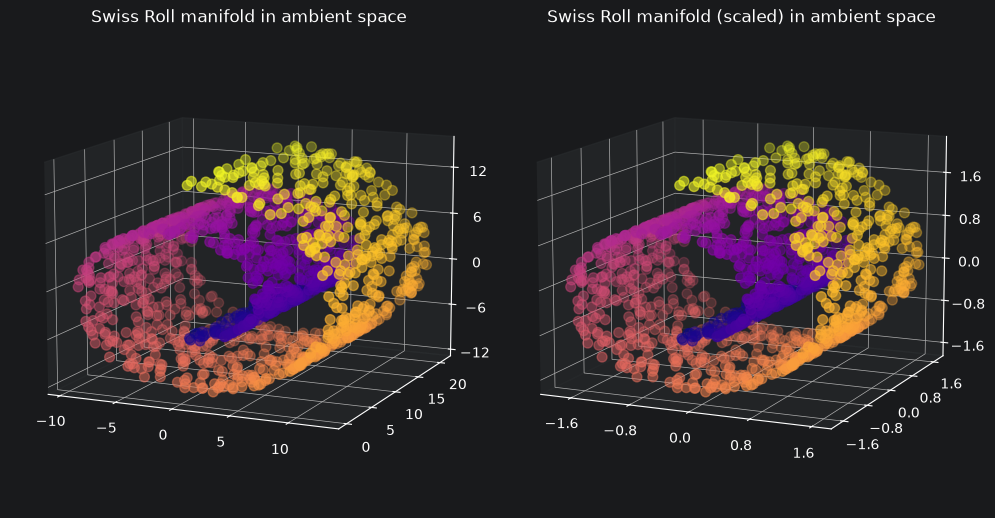

In [2]:
# generate data
from experiments.utils.plotting import visualize_manifold
X, y = MANIFOLD_GENERATOR()

# visualize 1/2
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 10))
ax0 = fig.add_subplot(121, projection="3d")
visualize_manifold(X, y, title=f"{MANIFOLD_NAME} manifold in ambient space", ax=ax0, hold_on=True);

# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
del X

# visualize 2/2
ax1 = fig.add_subplot(122, projection="3d")
visualize_manifold(X_scaled, y, title=f"{MANIFOLD_NAME} manifold (scaled) in ambient space", ax=ax1, hold_on=False);

## Modeling

In [3]:
from minisom_representation import calc_som_hyparams, SomRepresentation, plot_som_convergence_over_epochs

In [4]:
# use helper methods to get SOM hyperparameter recommendations
print("Recommended SOM parameters:", calc_som_hyparams(X_scaled))
print("Recommended SOM parameters:", calc_som_hyparams(X_scaled, initial_sigma_factor=3.0))

Recommended SOM parameters: {'d1': 14, 'd2': 15, 'sigma': 7.5}
Recommended SOM parameters: {'d1': 14, 'd2': 15, 'sigma': 5.0}


In [5]:
# define actual hyperparameters
recommended_params = calc_som_hyparams(X_scaled, initial_sigma_factor=3.0)
d1, d2 = recommended_params.get("d1"), recommended_params.get("d2")
sigma = recommended_params.get("sigma")
print("d1 x d2:", d1, "x", d2)
print("sigma:", sigma)
decay_function = "linear_decay_to_zero"
fit_type = "online"
epoch = None

d1 x d2: 14 x 15
sigma: 5.0


Evaluating for epochs of [ 1  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50]...
Training SOM for 1 epochs...
Training SOM for 2 epochs...
Training SOM for 4 epochs...
Training SOM for 6 epochs...
Training SOM for 8 epochs...
Training SOM for 10 epochs...
Training SOM for 12 epochs...
Training SOM for 14 epochs...
Training SOM for 16 epochs...
Training SOM for 18 epochs...
Training SOM for 20 epochs...
Training SOM for 22 epochs...
Training SOM for 24 epochs...
Training SOM for 26 epochs...
Training SOM for 28 epochs...
Training SOM for 30 epochs...
Training SOM for 32 epochs...
Training SOM for 34 epochs...
Training SOM for 36 epochs...
Training SOM for 38 epochs...
Training SOM for 40 epochs...
Training SOM for 42 epochs...
Training SOM for 44 epochs...
Training SOM for 46 epochs...
Training SOM for 48 epochs...
Training SOM for 50 epochs...


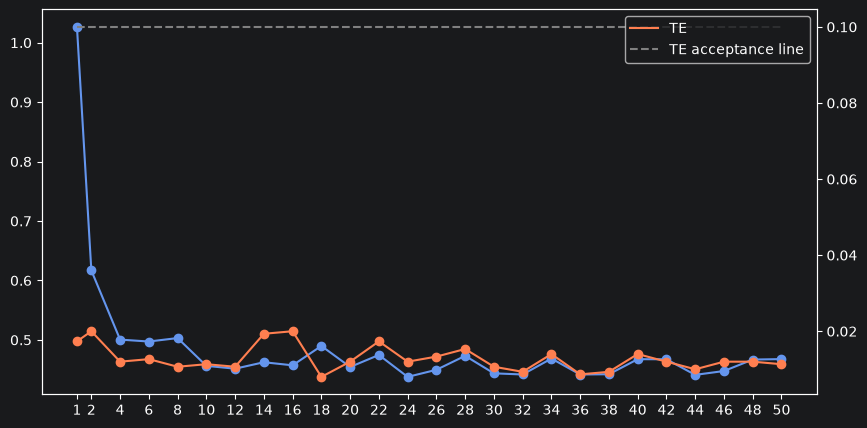


QE (first -> last): 	 1.03 -> 0.47
TE (first -> last): 	 0.02 -> 0.01


In [6]:
# test candidate values for `num_iteration` hyperparameter
fig, errors_qe, errors_te = plot_som_convergence_over_epochs(
    SomRepresentation(d1=d1, d2=d2, sigma=sigma, random_seed=RANDOM_SEED, verbose=False, decay_function=decay_function),
    X_scaled,
    fit_type=fit_type, te_ceiling=.1,
    epoch_step_from=2, epoch_step_to=50, epoch_step=2,
    figsize=(10, 5), show_fig=True, verbose=VERBOSE
)
print(f"\nQE (first -> last): \t {errors_qe[0]:.2f} -> {errors_qe[-1]:.2f}")
print(f"TE (first -> last): \t {errors_te[0]:.2f} -> {errors_te[-1]:.2f}")

In [8]:
# set selected `num_iteration` as epoch
epoch = 36

In [9]:
# fit SOM representation
som_rep = SomRepresentation(d1=d1, d2=d2, sigma=sigma, random_seed=RANDOM_SEED, verbose=VERBOSE, decay_function=decay_function) \
    .fit_online(X_scaled, num_iteration=epoch)

 [ 54000 / 54000 ] 100% - 0:00:00 left 
 quantization error: 0.44179753479958206

 An SOM representation has been fitted as follows:
------------------------------------------------------- 

Fit strategy: online 

Hyperparameters of SOM: 

{'input_len': 3, 'x': 14, 'y': 15, 'sigma': 5.0, 'topology': 'rectangular', 'learning_rate': 0.5, 'decay_function': 'linear_decay_to_zero', 'sigma_decay_function': 'asymptotic_decay', 'neighborhood_function': 'gaussian', 'activation_distance': 'euclidean', 'random_seed': 42, 'num_iteration': 36, 'use_epochs': True, 'random_order': True, 'verbose': True} 

Quality of SOM: 

Quantization Error (QE):	0.44179753479958206
Topographic Error (TE): 	0.008666666666666666


## Direct inspection of the fitted representation model

In [10]:
# extract SOM prototype weights
som = som_rep.som
node_weights = som.get_weights()
node_weights_flat = node_weights.reshape(-1, node_weights.shape[2])

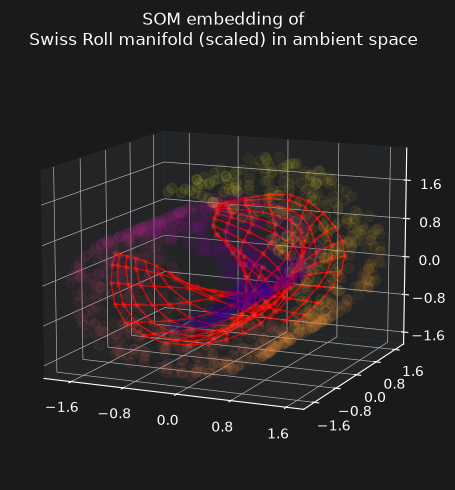

In [11]:
from utils.plotting import place_som_lattice
data_plot_style = { "alpha": 0.3 }
fig, ax = visualize_manifold(X_scaled, y, f"SOM embedding of\n{MANIFOLD_NAME} manifold (scaled) in ambient space", plot_style_args=data_plot_style, hold_on=True)
place_som_lattice(ax, node_weights, node_weights_flat)

## Inspection of the learned 2D topology

In [12]:
# create Basin
from lilypond import Basin
basin = Basin.from_som_representation(som_rep, random_seed=RANDOM_SEED, verbose=VERBOSE)

In [13]:
# traditional visuals
basin.legacy_pond().visualize_distance_map();
basin.legacy_pond().visualize_activation_map();

In [14]:
# lilypond visuals
basin.pond() \
    .rhizome_layer() \
    .pad_layer(gap="nogap") \
    .petal_layer(min_size=3, max_size=20) \
    .visualize(width=800, height=600);

## Register representation model in Databricks

In [15]:
from dotenv import load_dotenv
load_dotenv()

True

In [16]:
CATALOG = "workspace"
SCHEMA = "lilypond_experiments"
MODEL_NAME = "som-swissroll"
MODEL_PATH = f"{CATALOG}.{SCHEMA}.{MODEL_NAME}"
MODEL_PATH

'workspace.lilypond_experiments.som-swissroll'

In [17]:
import mlflow
import pandas as pd
from typing import Any

EXPERIMENT_NAME = "/Users/matebalogh@ophelia-rnd.dev/Bianor_LilypondExperiments_SwissRoll"
mlflow.set_experiment(experiment_name=EXPERIMENT_NAME)

class MLflowSomModelWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, model:SomRepresentation, scaler):
        self.model = model
        self.scaler = scaler
    def predict(self, context, model_input, params: dict[str, Any] | None = None):
        """First transforms the input data via scaler, then predicts the winner node of the SOM."""
        return [self.model.som.winner(x) for x in self.scaler.transform(model_input.to_numpy())]

with mlflow.start_run():
    model = MLflowSomModelWrapper(som_rep, scaler)

    mlflow.log_metric("QE", som_rep.quantization_error)
    mlflow.log_metric("TE", som_rep.topographic_error)

    mlflow.pyfunc.log_model(
        python_model=model,
        name=MODEL_NAME,
        input_example=pd.DataFrame(X_scaled[:3]),
        pip_requirements=[
            "numpy",
            "pandas",
            "scikit-learn==1.5.2",
            "mlflow",
            "minisom",
        ],
        registered_model_name=MODEL_PATH
    )

2026/09/02 22:42:57 INFO mlflow.tracking.fluent: Experiment with name '/Users/matebalogh@ophelia-rnd.dev/Bianor_LilypondExperiments_SwissRoll' does not exist. Creating a new experiment.
If you are using MLflow Tracing, consider storing your traces in Unity Catalog for unlimited storage (no 100,000 trace limit), fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/trace-unity-catalog
/opt/homebrew/Caskroom/miniconda/base/envs/wsom-lilypond-exp/lib/python3.11/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/09/02 22:43:07 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using C

🏃 View run magnificent-cub-588 at: dbc-ca44ccd5-3843.cloud.databricks.com/ml/experiments/3085108696545537/runs/b46ecbf262084d06951b275cdbb95625
🧪 View experiment at: dbc-ca44ccd5-3843.cloud.databricks.com/ml/experiments/3085108696545537


In [18]:
version = 1
registered_model = f"{MODEL_NAME}/{version}"
registered_model

'som-swissroll/1'

## Register metadata in Bianor

In [19]:
from databricks.connect import DatabricksSession
spark = DatabricksSession.builder.getOrCreate()

In [20]:
from bianor_databricks_kit import BianorRecordManager
bianor_recorder = BianorRecordManager(catalog=CATALOG, schema=SCHEMA, spark=spark)

In [21]:
registered_model_location = f"{CATALOG}.{SCHEMA}.{registered_model}"
registered_model_location

'workspace.lilypond_experiments.som-swissroll/1'

In [22]:
bianor_recorder.new_representation(name=f"{MANIFOLD_NAME} Manifold", som_model_location=registered_model_location, features_location="c.s.t") # FIXME